# Aufgabe: Ensemble Methoden 

In [2]:
# Importieren der Bibliotheken und Funktionen
# Zum Beispiel den Datensatz
from sklearn.datasets import load_wine

# Die verschiedenen Modelle aus der Aufgabe
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

import pandas as pd

from sklearn.model_selection import train_test_split

from tqdm.notebook import trange
from sklearn.metrics import classification_report

import math
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from os import error

import kagglehub
import sklearn
import seaborn as sns

### Aufgabe 1:

Laden Sie den Wine Datensatz und trainieren Sie folgende Modelle:

- [kNN Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- [Logistische Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier)
- [Random Forest Classifer](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- [AdaBoost Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html)

Zeigen Sie mittels einer geeigneten Metrik, welches Modell am besten geeignet ist.

Führen Sie im Anschluss all diese Modelle in ein großes Ensemble Modell zusammen. Verwenden Sie dafür den VotingClassifier von sklearn.

Ist Ihr VotingClassifier leistungsstärker als die einzelnen Modelle?


In [22]:
# Laden des Datensatzes

wine = load_wine()
x = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


C:\Users\fried\AppData\Local\Temp\ipykernel_43896\2989066366.py:22: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  density = stats.kde.gaussian_kde(col_data)


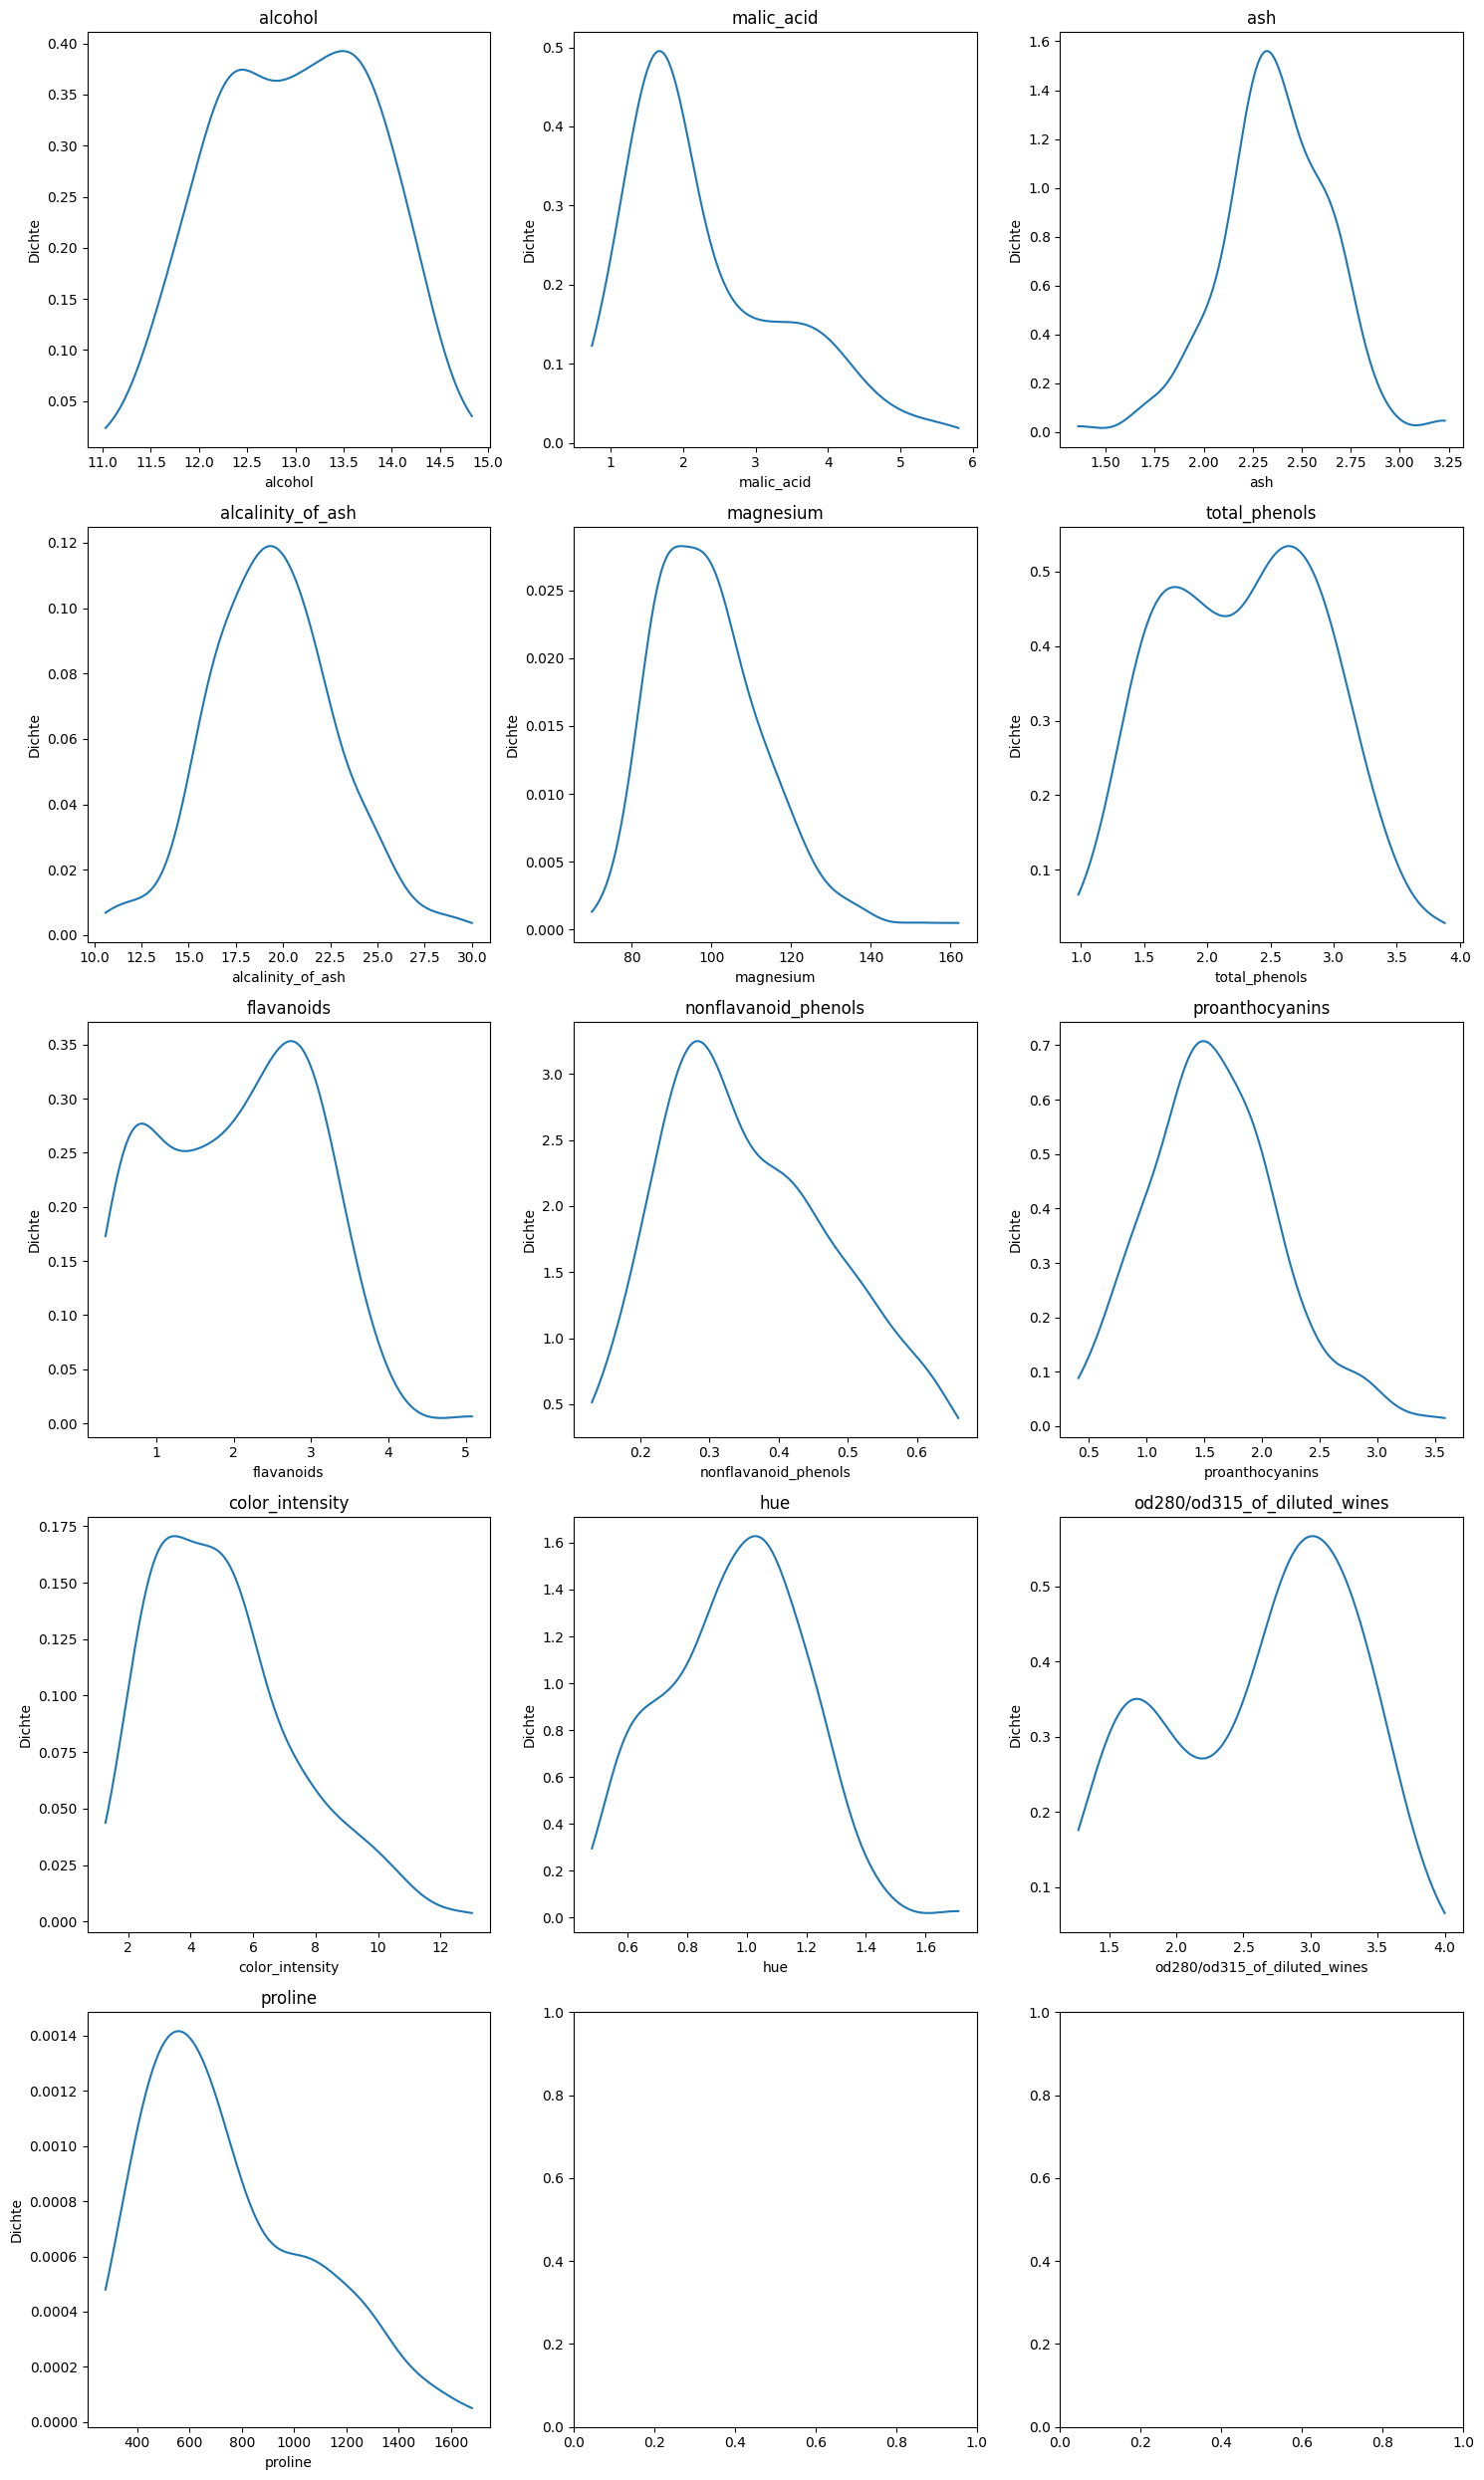

In [ ]:
# Rike kann nicht anders, Rike will den Datensatz kennenlernen


x.head()
x.describe()
wine_graph = wine.data
feature_names = wine.feature_names

n_features = wine_graph.shape[1]
n_cols_subplot = 3
n_rows = math.ceil(n_features / n_cols_subplot)

fig, axes = plt.subplots(n_rows, n_cols_subplot, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i in range(n_features):
    col_data = wine_graph[:, i]
    col_name = wine.feature_names[i]
    density = stats.kde.gaussian_kde(col_data)
    x = np.linspace(col_data.min(), col_data.max(), 300)
    axes[i].plot(x, density(x))
    axes[i].set_title(col_name)
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel("Dichte")

# Verstecke leere Subplots, falls weniger Spalten als Plätze
for j in range(len(wine.data), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


  0%|          | 0/29 [00:00<?, ?it/s]

Accuracy kNN:0.7183098591549296


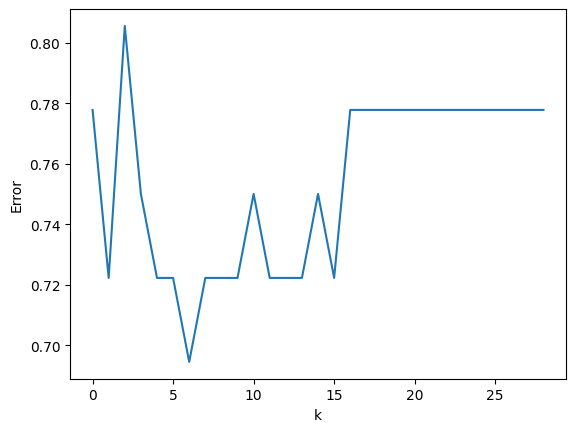

In [ ]:
# Gehe durch die definierten Modelle und trainiere sie
TrainScore = {}
# kNN
error_kNN = []
for k in trange(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    knn.score(x_train, y_train)
    y_pred_knn=knn.predict(x_test)
    error_kNN.append(knn.score(x_test, y_test))

plt.plot(error_kNN)
plt.xlabel("k")
plt.ylabel("Error")
#plt.show()
print("Accuracy kNN:" + str(knn.score(x_train, y_train)))
#print(classification_report(y_test, y_pred_knn))

knn_opt = KNeighborsClassifier(n_neighbors=20)
knn_opt.fit(x_train, y_train)
TrainScore["kNN"] = knn_opt.score(x_train, y_train)


In [40]:
# Logistic Regression

log_reg = LogisticRegression(multi_class="multinomial", # kann mehr als 2 Klassen unterscheiden
                             solver="lbfgs", # unterstützt multinomial
                             max_iter=500)
log_reg.fit(x_train, y_train)
y_pred_log_reg = log_reg.predict(x_test)
TrainScore["Logistic Regression"] = log_reg.score(x_train, y_train)
#print(classification_report(y_test, y_pred_log_reg))
#print("Accuracy Logistic Regression:" + str(log_reg.score(x_train, y_train)))


c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  0%|          | 0/9 [00:00<?, ?it/s]

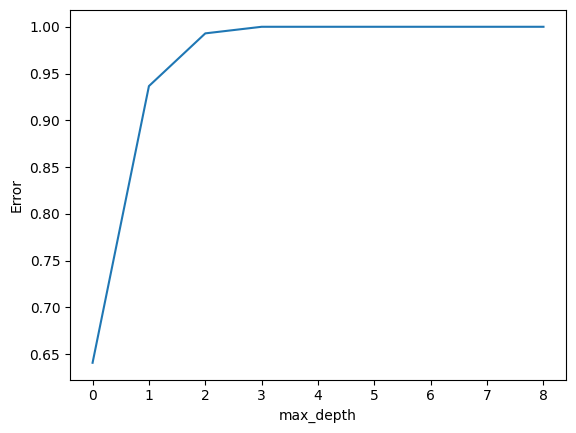

In [ ]:
#Decision Tree Classifier

error_tree=[]
for depth in trange(1,10):
    tree=DecisionTreeClassifier(max_depth=depth)
    tree.fit(x_train,y_train)
    tree.score(x_train,y_train)
    error_tree.append(tree.score(x_train,y_train))


plt.plot(error_tree)
plt.xlabel("max_depth")
plt.ylabel("Error")
#print("Accuracy Decision Tree:" + str(tree.score(x_train,y_train)))

tree_opt = DecisionTreeClassifier(max_depth=2)
tree_opt.fit(x_train,y_train)
TrainScore["Decision Tree"] = tree_opt.score(x_train, y_train)


In [47]:
# Random Forest Classifier

forest=RandomForestClassifier(max_depth = 2, n_estimators=10, random_state=42)
forest.fit(x_train,y_train)
forest.score(x_train, y_train)
print("Accuracy Random Forest:" + str(forest.score(x_train, y_train)))
TrainScore["Random Forest"] = forest.score(x_train, y_train)


Accuracy Random Forest:0.9859154929577465


In [58]:
# AdaBoostCassifier
adaboost=AdaBoostClassifier(n_estimators=10, random_state=42)
adaboost.fit(x_train,y_train)
adaboost.score(x_train,y_train)
print("Accuracy AdaBoost:" + str(adaboost.score(x_train,y_train)))
TrainScore["AdaBoosting"] = adaboost.score(x_train,y_train)


Accuracy AdaBoost:0.9929577464788732


                 Model  Score on Training Data
0                  kNN                0.732394
1  Logistic Regression                0.971831
2        Decision Tree                0.936620
3        Random Forest                0.985915
4          AdaBoosting                0.992958
5    Voting Classifier                0.992958


<function matplotlib.pyplot.show(close=None, block=None)>

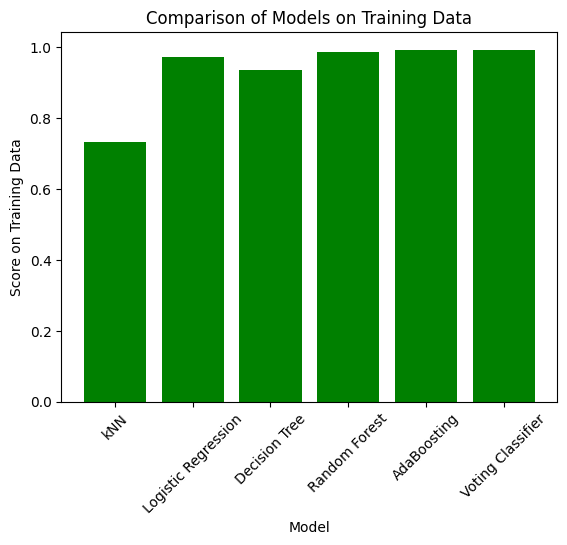

In [106]:

#print(TrainScore)

df_trainscore=pd.DataFrame(list(TrainScore.items()), columns=["Model", "Score on Training Data"])
print(df_trainscore)
plt.bar(df_trainscore["Model"], df_trainscore["Score on Training Data"], color=["green"])
plt.xlabel("Model")
plt.ylabel("Score on Training Data")
plt.title("Comparison of Models on Training Data")
plt.xticks(rotation=45)
plt.show

In [66]:
# Definiere einen Voting Classifier mit allen Modellen
voting_clf = VotingClassifier(
    estimators=[
        ("knn", knn_opt),
        ("log_reg", log_reg),
        ("tree", tree_opt),
        ("forest", forest),
        ("adaboost", adaboost),
    ],
    voting="soft",
)
voting_clf.fit(x_train, y_train)
voting_clf.score(x_train, y_train)
TrainScore["Voting Classifier"] = voting_clf.score(x_train, y_train)
y_pred=voting_clf.predict(x_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.93      1.00      0.97        14
           2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



### Aufgabe 2: Random Forest

Trainieren Sie Decision Tree sowie Random Forest (zB aus sklearn) an dem von Ihnen für die Abschlussarbeit gewählten Datensatz. Visualisieren Sie (wenn möglich) das Ergebnis, welches Modell liefert bessere Ergebnisse? Welches Modell wäre vielleicht noch besser geeignet?


In [ ]:
# Hier sollte ein selbst gewählter Datensatz individuell gewählt werden


# Download latest version
path = kagglehub.dataset_download("joniarroba/noshowappointments")

print("Path to dataset files:", path)

noshow=pd.read_csv(path + "/KaggleV2-May-2016.csv")
print(noshow.head())



Path to dataset files: C:\Users\fried\.cache\kagglehub\datasets\joniarroba\noshowappointments\versions\5
      PatientId  AppointmentID Gender          ScheduledDay  \
0  2.987250e+13        5642903      F  2016-04-29T18:38:08Z   
1  5.589978e+14        5642503      M  2016-04-29T16:08:27Z   
2  4.262962e+12        5642549      F  2016-04-29T16:19:04Z   
3  8.679512e+11        5642828      F  2016-04-29T17:29:31Z   
4  8.841186e+12        5642494      F  2016-04-29T16:07:23Z   

         AppointmentDay  Age      Neighbourhood  Scholarship  Hipertension  \
0  2016-04-29T00:00:00Z   62    JARDIM DA PENHA            0             1   
1  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             0   
2  2016-04-29T00:00:00Z   62      MATA DA PRAIA            0             0   
3  2016-04-29T00:00:00Z    8  PONTAL DE CAMBURI            0             0   
4  2016-04-29T00:00:00Z   56    JARDIM DA PENHA            0             1   

   Diabetes  Alcoholism  Handcap  SMS_received 

C:\Users\fried\AppData\Local\Temp\ipykernel_38392\1722445750.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  noshow["No-show"] = noshow["No-show"].replace({"Yes": 1, "No": 0})
C:\Users\fried\AppData\Local\Temp\ipykernel_38392\1722445750.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  noshow["Gender"]=noshow["Gender"].replace({"F": 1, "M": 0})


  0%|          | 0/29 [00:00<?, ?it/s]

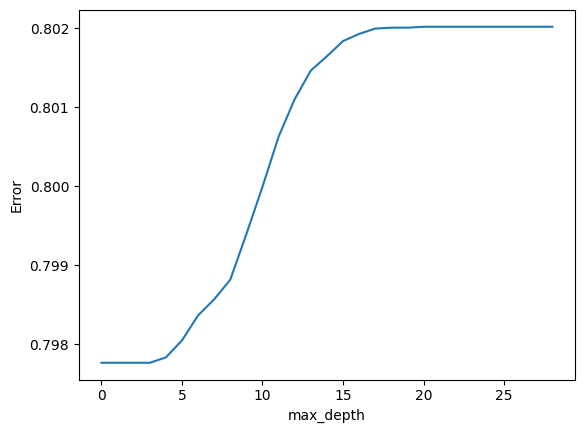

In [ ]:
#Preprocessing
noshow["No-show"] = noshow["No-show"].replace({"Yes": 1, "No": 0})
noshow["Gender"]=noshow["Gender"].replace({"F": 1, "M": 0}) # wäre nicht nötig

x = noshow.drop(
    columns=[
        "PatientId",
        "AppointmentID",
        "ScheduledDay",
        "AppointmentDay",
        "Neighbourhood",
        "No-show",
    ]
)
y = noshow["No-show"]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
# print(x.head())
# Decision Tree, Tiefe des Baumes optimieren
error_model_tree = []
# Vergleiche die möglichen Metriken und Darstellung zB mit der plot_tree Funktion von sklearn
for depth in trange(1, 30):
    model_tree = DecisionTreeClassifier(max_depth=depth)
    model_tree.fit(x_train, y_train)
    model_tree.score(x_train, y_train)
    error_model_tree.append(model_tree.score(x_train, y_train))

plt.plot(error_model_tree)
plt.xlabel("max_depth")
plt.ylabel("Error")
plt.show()




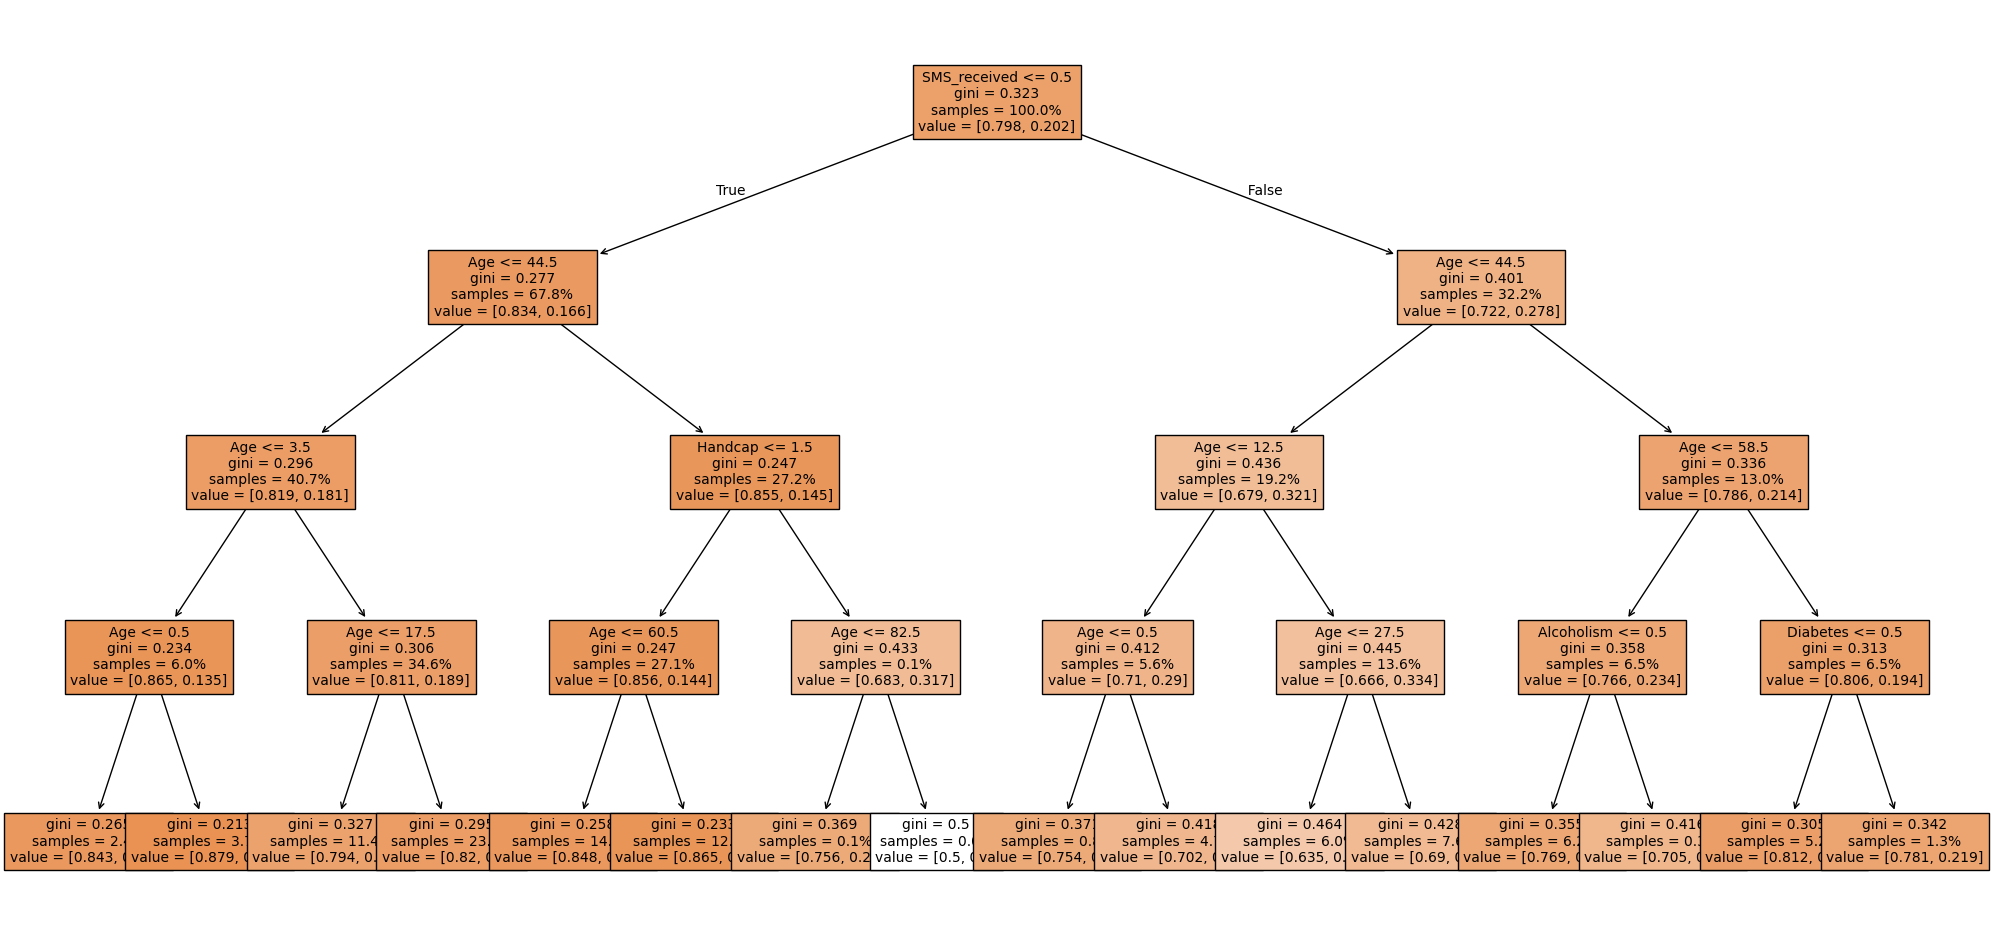

In [112]:
# Baum plotten
plt.figure(figsize=(25, 12))
tree_plot = DecisionTreeClassifier(max_depth=4)
tree_plot.fit(x_train, y_train)
sklearn.tree.plot_tree(
    tree_plot,
    feature_names=x.columns,
    filled=True,
    proportion=True,
    fontsize=10,
)
plt.show()


  0%|          | 0/49 [00:00<?, ?it/s]

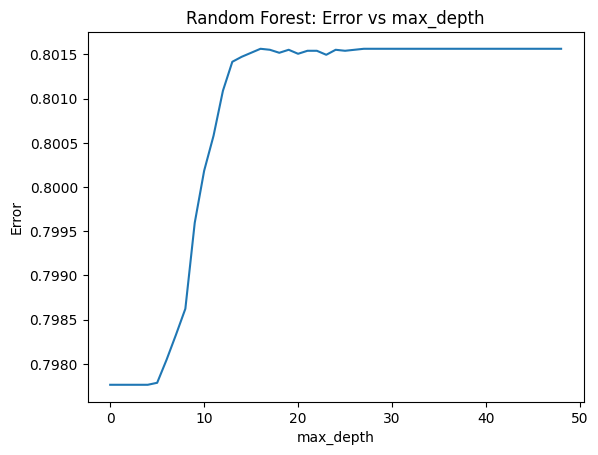

  0%|          | 0/49 [00:00<?, ?it/s]

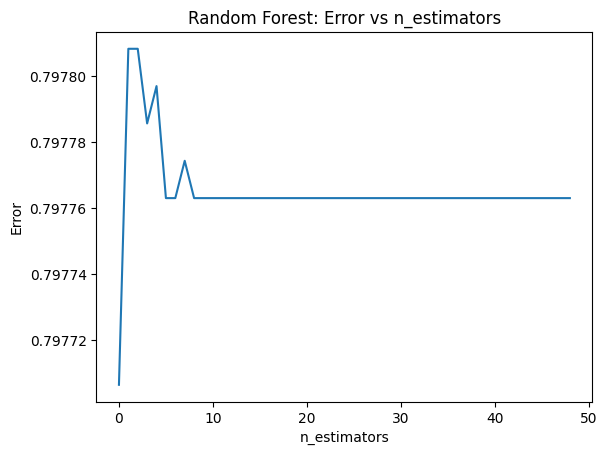

In [110]:
#Random Forest
error_model_depth=[]
for depth in trange(1,50):
    model_forest=RandomForestClassifier(max_depth=depth, n_estimators=10, random_state=42)
    model_forest.fit(x_train, y_train)
    model_forest.score(x_train, y_train)
    error_model_depth.append(model_forest.score(x_train, y_train))

plt.plot(error_model_depth)
plt.xlabel("max_depth")
plt.ylabel("Error")
plt.title("Random Forest: Error vs max_depth")
plt.show()

model_forest_opt = RandomForestClassifier(max_depth=4, n_estimators=5, random_state=42)

error_model_estimator =[]
for estim in trange(1,50):
    model_forest=RandomForestClassifier(max_depth=5, n_estimators=estim, random_state=42)
    model_forest.fit(x_train, y_train)
    model_forest.score(x_train, y_train)
    error_model_estimator.append(model_forest.score(x_train, y_train))

plt.plot(error_model_estimator)
plt.xlabel("n_estimators")
plt.ylabel("Error")

plt.title("Random Forest: Error vs n_estimators")
plt.show()

In [ ]:
#Vergleich Decision Tree und Random Forest
model_tree_opt = DecisionTreeClassifier(max_depth=20)
model_tree_opt.fit(x_train, y_train)
#model_tree_opt.score(x_test, y_test)
print("Accuracy Decision Tree:" + str(model_tree_opt.score(x_test, y_test)))

model_forest_opt = RandomForestClassifier(max_depth=20, n_estimators=5, random_state=42)
model_forest_opt.fit(x_train, y_train)
#model_forest_opt.score(x_test, y_test)
print("Accuracy Random Forest:" + str(model_forest_opt.score(x_test, y_test)))

Accuracy Decision Tree:0.7969781959648964
Accuracy Random Forest:0.7948520763593595


In [ ]:
noshow.describe()
y.value_counts()

,PatientId,AppointmentID,Gender,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,0.649977,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,0.201933
std,2.560949e+14,7.129575e+04,0.476979,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,0.401444
min,3.921784e+04,5.030230e+06,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,1.000000,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,1.000000,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,9.999816e+14,5.790484e+06,1.000000,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000


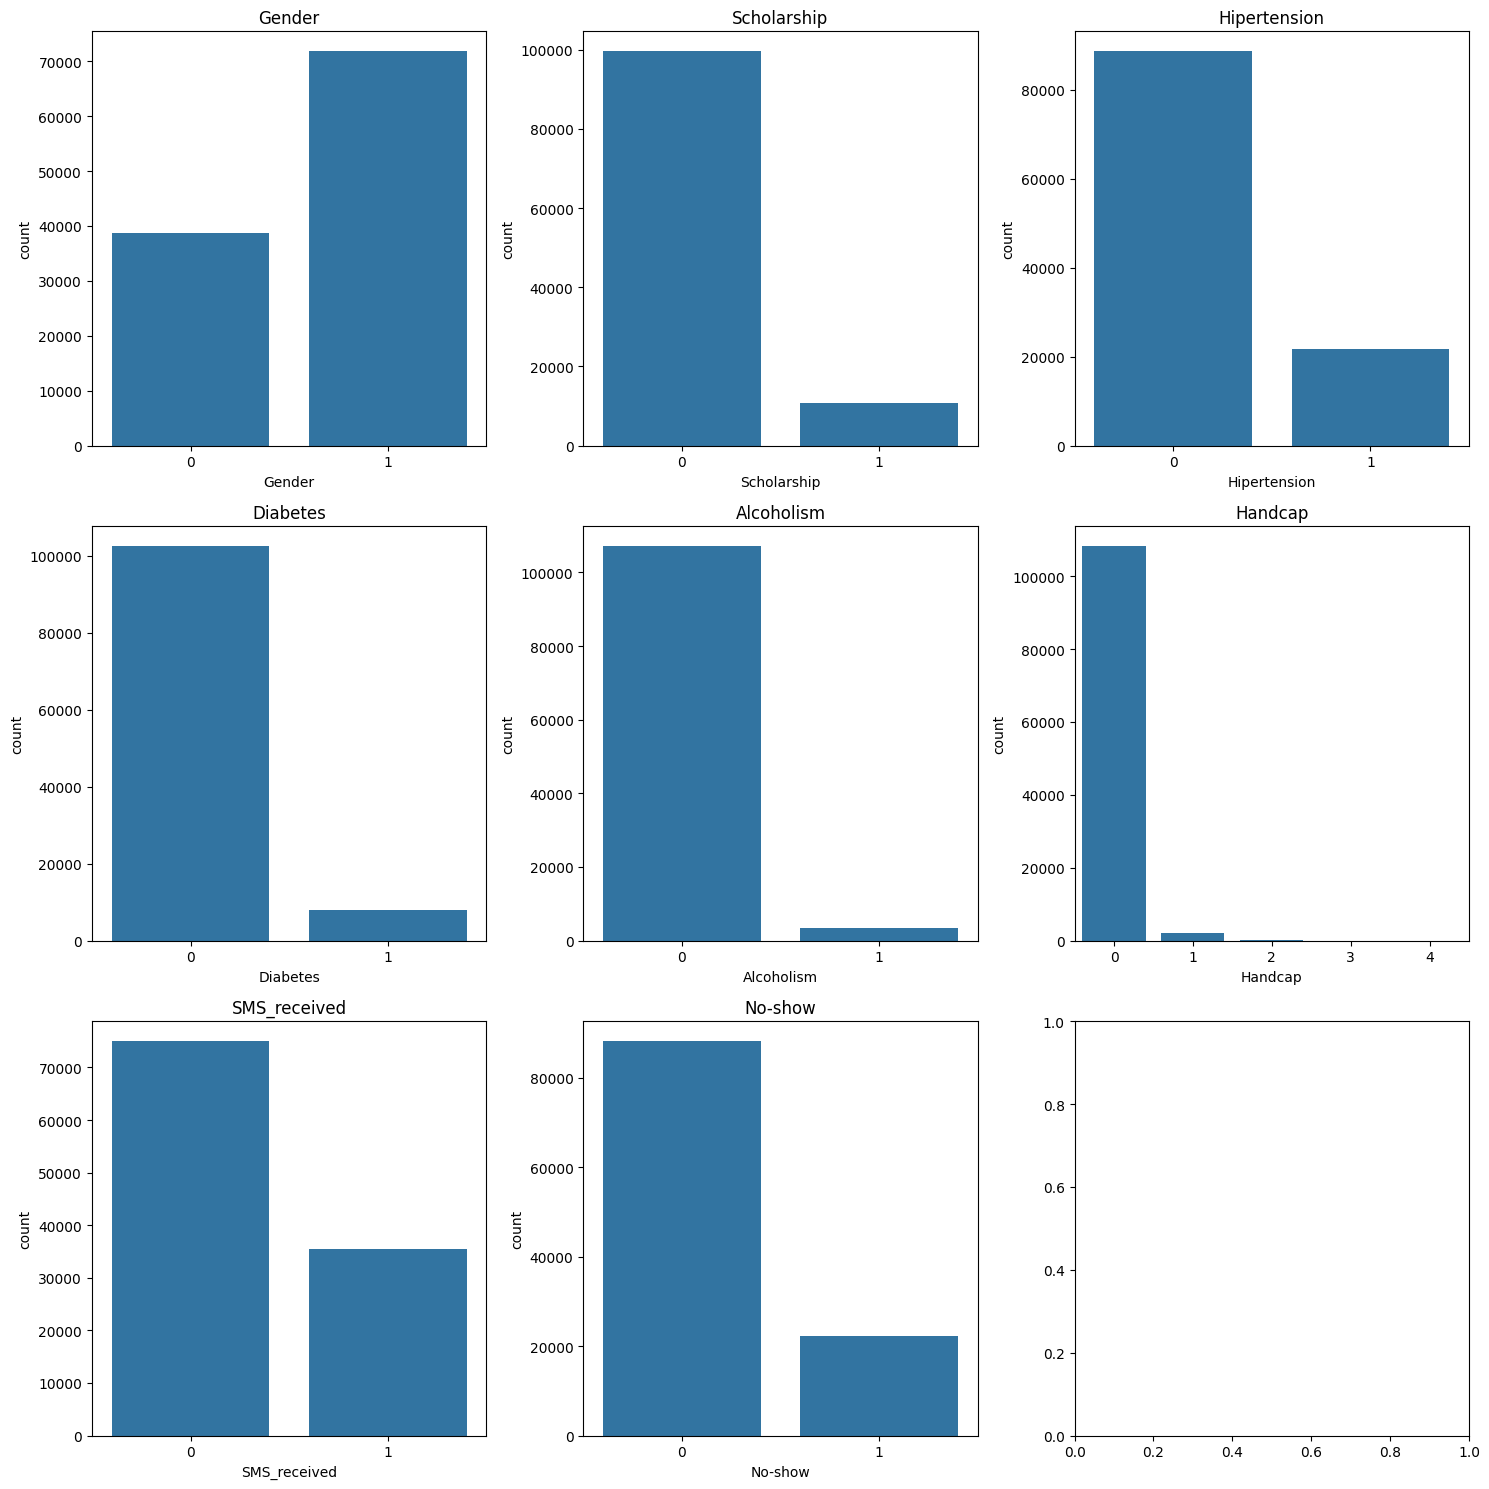

In [ ]:

cat_cols=[col for col in noshow.columns if noshow[col].nunique() <= 10]

n_features = len(cat_cols)
n_cols_subplot = 3
n_rows = math.ceil(n_features / n_cols_subplot)

fig, axes = plt.subplots(n_rows, n_cols_subplot, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=noshow[col], ax=axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()


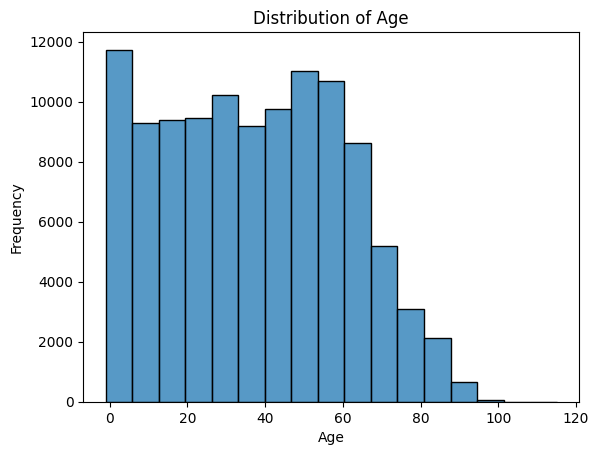

In [16]:

age=noshow["Age"]
#age.value_counts()
bin_number = int(1 + np.log2(len(age)))
bins = np.histogram_bin_edges(age, bins="sturges")

plt.figure()
sns.histplot(age, bins=bin_number)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()


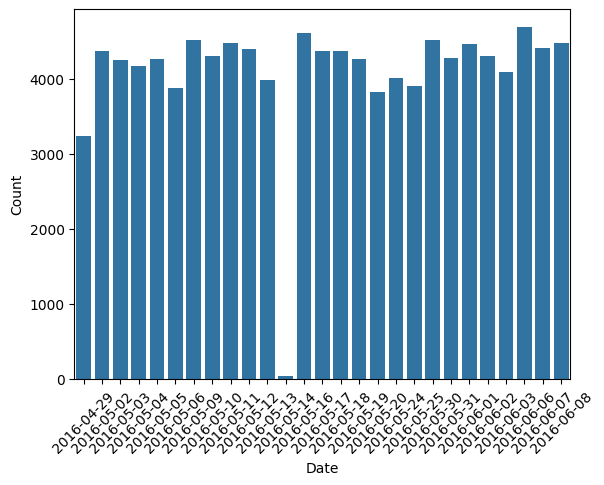

In [23]:
noshow_date= pd.to_datetime(noshow["AppointmentDay"])
noshow_dayname = noshow_date.dt.day_name()
noshow_day=noshow_date.dt.date
daycount=noshow_day.value_counts().sort_index()

plot_day=daycount.reset_index()
plot_day.columns=["Date", "Count"]

sns.barplot(data=plot_day, x="Date", y="Count")
plt.xticks(rotation=45)
plt.show()
